In [28]:
%%capture
! pip install laspy open3d

In [1]:
%%capture
! pip install shapely laspy
# Standard library imports
import os
import warnings
import collections
import itertools
from typing import Tuple, List, Union, Generator

# Numerical and data manipulation libraries
import numpy as np
import pandas as pd
import scipy
from scipy.spatial import KDTree

# Geospatial libraries
import geopandas as gpd
import shapely

# LAS (LiDAR) file handling
import laspy
from laspy import read

# Visualization libraries
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns

In [2]:
def load_las_file(file_path: str) -> laspy.LasData:
    """
    Load a .las file and return the full laspy.LasData object.
    """
    try:
        las = laspy.read(file_path)
        return las
    except Exception as e:
        print(f"Error loading file: {e}")
        return None

In [3]:
def shift_points_to_origin(points) -> np.ndarray:
    """
    Shift points to the origin (0, 0, 0) by subtracting the minimum coordinates.
    """
    return points - points.min(axis=0, keepdims=True)


In [4]:
def plot_shifted_lidar(lidar_file: str):
    """
    Plot a 3D LiDAR point cloud with ground points in red. Coordinates are shifted for better visualization.
    """
    try:
        las = laspy.read(lidar_file)
        points = np.stack([las.x, las.y, las.z], axis=1)
        classifications = las.classification

        # shift points to start from (0, 0, 0)
        points = shift_points_to_origin(points)
        ground_mask = classifications == 2
        ground_points = points[ground_mask]
        other_points = points[~ground_mask]

        file_name = os.path.splitext(os.path.basename(lidar_file))[0]

        fig = plt.figure(figsize=(6, 6))
        ax = fig.add_subplot(111, projection="3d")

        ax.scatter(
            ground_points[:, 0],
            ground_points[:, 1],
            ground_points[:, 2],
            c="red",
            s=0.5,
            label="Ground Points",
        )

        ax.scatter(
            other_points[:, 0],
            other_points[:, 1],
            other_points[:, 2],
            c=other_points[:, 2],
            cmap="viridis",
            s=0.5,
        )

        ax.set_title("LiDAR Point Cloud Visualization (Shifted)")
        ax.set_xlabel("X")
        ax.set_ylabel("Y")
        ax.set_zlabel("Z")

        ax.view_init(elev=30, azim=45)
        ax.legend(loc="upper right", markerscale=5, fontsize=10)

        plt.figtext(0.5, 0.01, f"{file_name}", ha="center", style="italic")

        plt.show()

    except Exception as e:
        print(f"Error visualizing LiDAR file: {e}")

In [5]:
def calculate_iqr_outliers(z_values: np.ndarray) -> Tuple[float, float]:
    """
    Calculate the lower and upper bounds for outliers in Z values based on the IQR method.
    """
    q1 = np.percentile(z_values, 25)  # 25th percentile (Q1)
    q3 = np.percentile(z_values, 75)  # 75th percentile (Q3)
    iqr = q3 - q1  # Interquartile range (IQR)

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    return lower_bound, upper_bound

In [6]:
def plot_z_distribution(z_values: np.ndarray, ax, file_name: str):
    """
    Plot the Z-value distribution for the given z-values on a specific subplot, with outlier boundaries.
    """
    lower_bound, upper_bound = calculate_iqr_outliers(z_values)

    # Plot histogram
    ax.hist(z_values, bins=50, color="green", alpha=0.7, label="Z Values")

    # Add IQR outlier lines
    ax.axvline(lower_bound, color="red", linestyle="--", label=f"Lower: {lower_bound:.2f}")
    ax.axvline(upper_bound, color="red", linestyle="--", label=f"Upper: {upper_bound:.2f}")

    ax.set_title(file_name, fontsize=10)
    ax.set_xlabel("Z Value (Height)", fontsize=8)
    ax.set_ylabel("Frequency", fontsize=8)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

In [7]:
LAS_GROUND_CLASS = 2

def normalize_cloud_height(las):
    out = las.xyz.copy()
    assert np.any(las.classification == LAS_GROUND_CLASS)
    ground_level = scipy.interpolate.griddata(
        points=las.xyz[las.classification == LAS_GROUND_CLASS, :2], # X, Y coordinates of the ground points.
        values=las.xyz[las.classification == LAS_GROUND_CLASS, 2], # The Z-values (heights) of the ground points.
        xi=las.xyz[:, :2], # X, Y coordinates of all points in the las file.
        method="nearest",
    )
    out[:, 2] -= ground_level # Subtracts the interpolated ground height (ground_level) from the Z-value of each point.
    return out

In [8]:
def preprocess_data(las) -> np.ndarray:
    """
    Preprocess LiDAR points by normalizing heights relative to ground and removing outliers.
    """
    normalized_cloud = normalize_cloud_height(las)

    z_values = normalized_cloud[:, 2]
    lower_bound, upper_bound = calculate_iqr_outliers(z_values)
    mask = (z_values >= lower_bound) & (z_values <= upper_bound)

    filtered_points = normalized_cloud[mask]

    return filtered_points

In [9]:
def split_dataset(data: List, train_ratio: float = 0.7) -> Tuple[List, List]:
    """
    Splits the dataset into training and testing sets based on the given ratio.
    """
    split_idx = int(len(data) * train_ratio)

    train_data = data[:split_idx]
    test_data = data[split_idx:]

    return train_data, test_data

In [10]:
def local_maxima_filter(cloud: np.ndarray, window_size: float, height_threshold: float) -> np.ndarray:
    """Detect local maxima in the point cloud with a fixed window size."""

    assert isinstance(cloud, np.ndarray), f"Cloud needs to be a numpy array, not {type(cloud)}"

    cloud = cloud[cloud[:, 2] > height_threshold]
    tree = KDTree(data=cloud)
    seen_mask = np.zeros(cloud.shape[0], dtype=bool)
    local_maxima = []

    for i, point in enumerate(cloud):
        if seen_mask[i]:
            continue
        neighbor_indices = tree.query_ball_point(point, window_size)
        highest_neighbor = neighbor_indices[cloud[neighbor_indices, 2].argmax()]
        seen_mask[neighbor_indices] = True
        seen_mask[highest_neighbor] = False
        # This may lead to not every point being marked as seen in the end, but it does not matter,
        # because by the time the seen value is overwritten the point is already processed
        if i == highest_neighbor:
            local_maxima.append(i)
    return cloud[local_maxima]

In [11]:
def _ndarray_to_tuple(array: np.ndarray) -> tuple:
    """Convert an array to a tuple, replacing np.nan with None."""
    return tuple(None if np.isnan(x) else x for x in array)


In [12]:
def match_candidates(
    ground_truth: np.ndarray,
    candidates: np.ndarray,
    *,
    max_distance: float,
    max_height_difference: float,
) -> list[dict]:
    """Match ground truth trees to candidates."""

    distance_matrix = scipy.spatial.distance_matrix(
        x=ground_truth[:, :2],
        y=candidates[:, :2],
    )
    indices = np.nonzero(distance_matrix <= max_distance)  # (ground_truths, candidates)
    distances = distance_matrix[indices]
    sparse_distances = sorted((d, pair) for d, pair in zip(distances, zip(*indices)))

    ground_truth_matched_mask = np.zeros(ground_truth.shape[0], dtype=bool)
    candidates_matched_mask = np.zeros(candidates.shape[0], dtype=bool)
    out = []

    for distance, (i, j) in sparse_distances:
        if ground_truth_matched_mask[i] and candidates_matched_mask[j]:
            continue

        if (
            not np.isnan(ground_truth[i][2])
            and abs(ground_truth[i][2] - candidates[j][2]) > max_height_difference
        ):
            continue

        if ground_truth_matched_mask[i]:
            candidates_matched_mask[j] = True
            out.append(
                {
                    "ground_truth": None,
                    "candidate": _ndarray_to_tuple(candidates[j]),
                    "class": "FP",
                    "distance": None,
                }
            )
        elif candidates_matched_mask[j]:
            ground_truth_matched_mask[i] = True
            out.append(
                {
                    "ground_truth": _ndarray_to_tuple(ground_truth[i]),
                    "candidate": None,
                    "class": "FN",
                    "distance": None,
                }
            )
        else:
            ground_truth_matched_mask[i] = True
            candidates_matched_mask[j] = True
            out.append(
                {
                    "ground_truth": _ndarray_to_tuple(ground_truth[i]),
                    "candidate": _ndarray_to_tuple(candidates[j]),
                    "class": "TP",
                    "distance": distance,
                }
            )

    out.extend(
        {
            "ground_truth": _ndarray_to_tuple(point),
            "candidate": None,
            "class": "FN",
            "distance": None,
        }
        for point in ground_truth[~ground_truth_matched_mask]
    )

    out.extend(
        {
            "ground_truth": None,
            "candidate": tuple(point),
            "class": "FP",
            "distance": None,
        }
        for point in candidates[~candidates_matched_mask]
    )

    return out

In [13]:
def crop_by_other(points: np.ndarray, other: np.ndarray) -> np.ndarray:
    """Crop points by the extent of other."""
    hull = scipy.spatial.ConvexHull(other[:, :2])
    vertex_points = hull.points[hull.vertices]
    delaunay = scipy.spatial.Delaunay(vertex_points)
    within_hull = delaunay.find_simplex(points[:, :2]) >= 0
    return points[within_hull]

In [14]:
def calculate_metrics(group):
    classes = collections.Counter(group["class"])
    metrics = {
        "recall": classes["TP"] / (classes["TP"] + classes["FN"]),
        "precision": classes["TP"] / (classes["TP"] + classes["FP"]),
    }
    if metrics["recall"] + metrics["precision"] > 0:
        metrics["f1"] = 2 * metrics["recall"] * metrics["precision"]
        metrics["f1"] = metrics["f1"] / (metrics["recall"] + metrics["precision"])
    else:
        metrics["f1"] = 0
    metrics["avg_dist"] = group["distance"].mean()
    return round(pd.Series(metrics), 2)

In [15]:
plot_las_files = [f"data/als/plot_{i:02d}.las" for i in range(1, 11)]

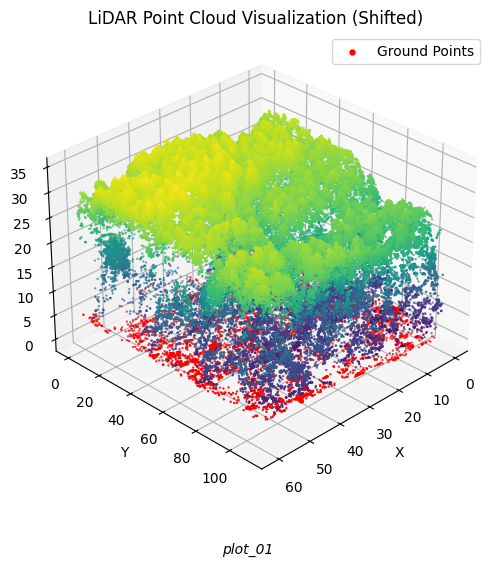

In [16]:
plot_shifted_lidar(plot_las_files[0])


Processing plot_01.las...
Processing plot_02.las...
Processing plot_03.las...
Processing plot_04.las...
Processing plot_05.las...
Processing plot_06.las...
Processing plot_07.las...
Processing plot_08.las...
Processing plot_09.las...
Processing plot_10.las...


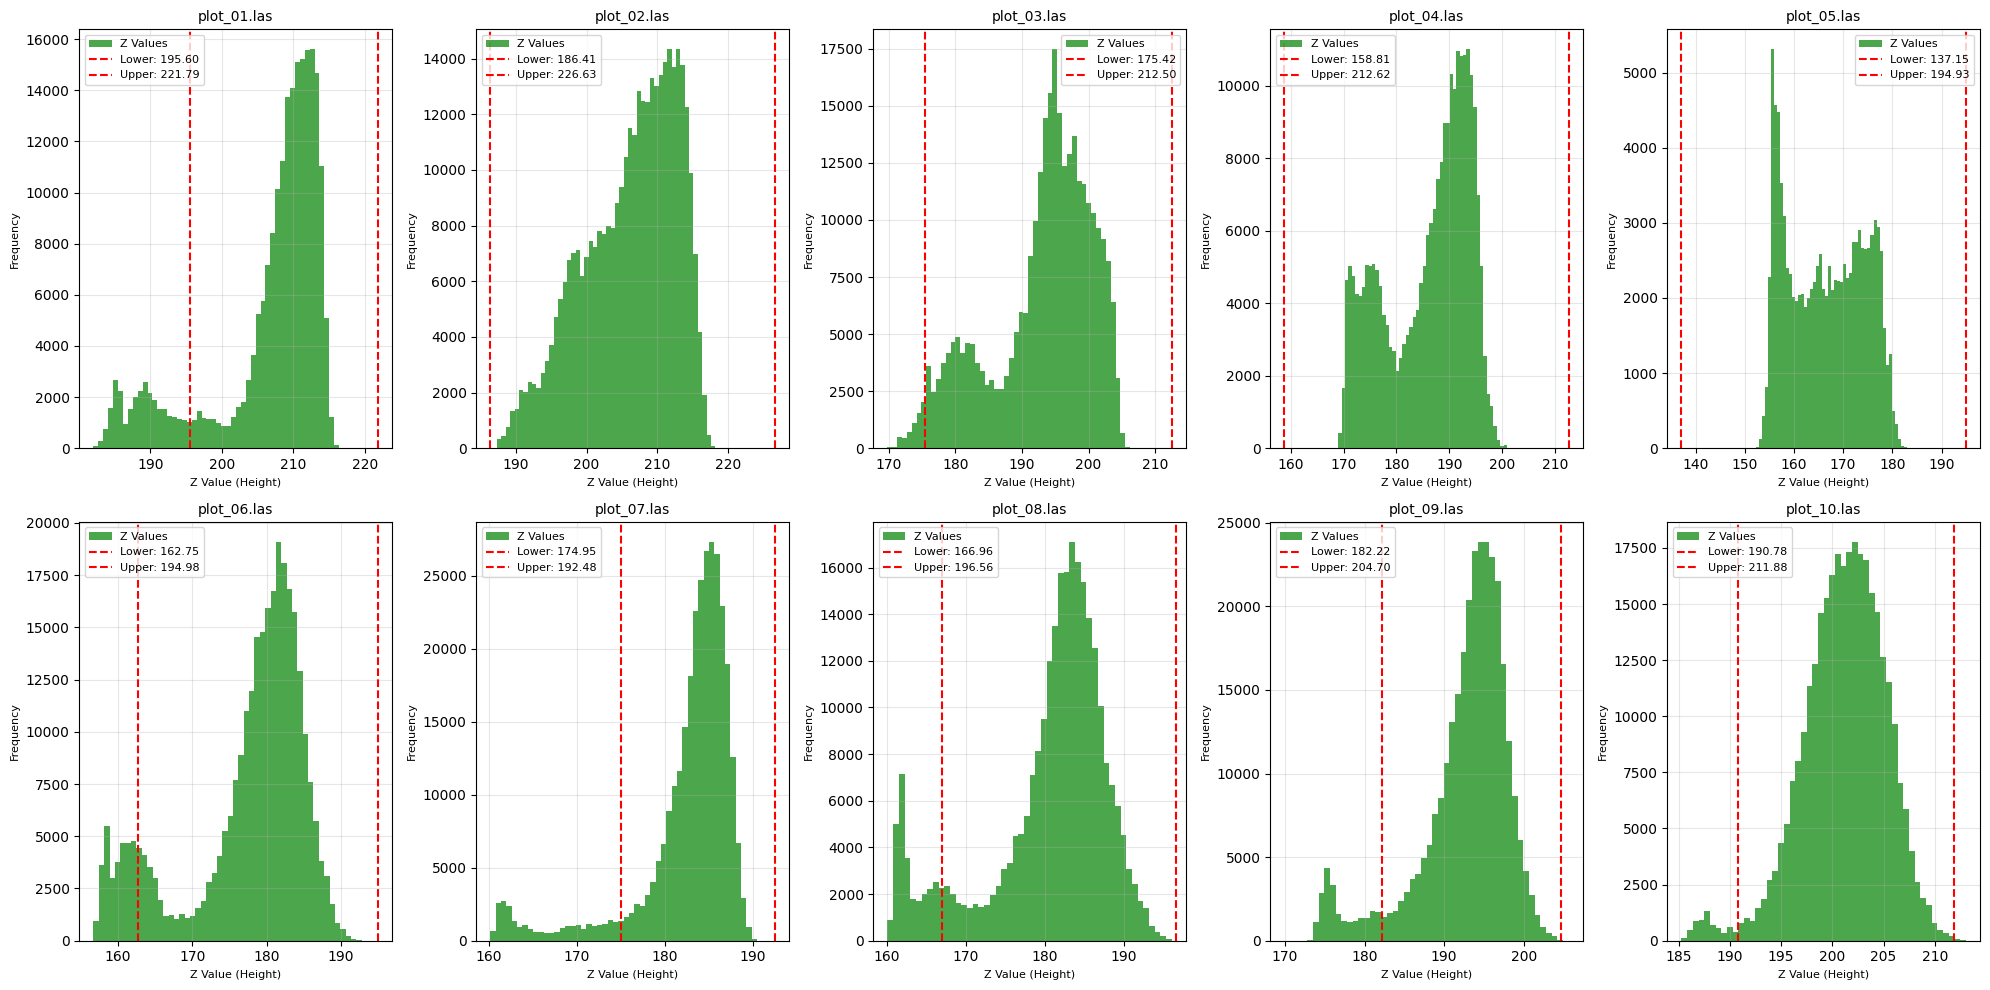

In [17]:
fig, axes = plt.subplots(2, 5, figsize=(20, 10))
axes = axes.flatten()

for i, file_path in enumerate(plot_las_files[:10]):
    file_name = os.path.basename(file_path)
    print(f"Processing {file_name}...")

    las = load_las_file(file_path)
    if las is None or len(las.x) == 0:
        print(f"Skipping {file_name} due to an error or no valid points.")
        continue

    plot_z_distribution(las.z, axes[i], file_name)

plt.tight_layout()
plt.show()

In [18]:
field_survey_gpd = gpd.read_file("data/field_survey.geojson")
field_survey_gpd["coords"] = field_survey_gpd.get_coordinates().apply(
    lambda x: (x["x"], x["y"]),
    axis=1,
)

In [19]:
preprocessed_data = []

for file_path in plot_las_files:

    las = load_las_file(file_path)

    if las is not None and len(las.x) > 0:
        preprocessed_points = preprocess_data(las)
        preprocessed_data.append(preprocessed_points)
    else:
        print(f"Skipping {file_path} due to no valid points.")

for i, points in enumerate(preprocessed_data):
    print(f"File {i + 1}: {len(points)} preprocessed points")

File 1: 186897 preprocessed points
File 2: 355599 preprocessed points
File 3: 282788 preprocessed points
File 4: 251251 preprocessed points
File 5: 105771 preprocessed points
File 6: 263587 preprocessed points
File 7: 284775 preprocessed points
File 8: 240625 preprocessed points
File 9: 289525 preprocessed points
File 10: 307468 preprocessed points


In [20]:
train_ratio = 0.7
train_data, test_data = split_dataset(preprocessed_data, train_ratio)

In [21]:
window_size = 3  # Radius for neighbor search
height_threshold = 2  # Minimum height to consider

for i, points in enumerate(preprocessed_data):
    local_maxima_points = local_maxima_filter(points, window_size, height_threshold)
    print(f"Detected {len(local_maxima_points)} local maxima in training file {i + 1}.")



Detected 236 local maxima in training file 1.
Detected 159 local maxima in training file 2.
Detected 248 local maxima in training file 3.
Detected 189 local maxima in training file 4.
Detected 221 local maxima in training file 5.
Detected 301 local maxima in training file 6.
Detected 160 local maxima in training file 7.
Detected 244 local maxima in training file 8.
Detected 186 local maxima in training file 9.
Detected 165 local maxima in training file 10.


In [22]:
raw_matches = {}
results = {}

for i, points in enumerate(preprocessed_data):
    plot = i + 1

    # Load ground truth data for the current plot
    subset = field_survey_gpd.query(f"plot == {plot}")
    ground_truth = subset.get_coordinates().to_numpy()
    ground_truth = np.hstack([ground_truth, subset["height"].to_numpy()[:, None]])

    # Detect local maxima
    candidates = local_maxima_filter(
        cloud=points,
        window_size=2,
        height_threshold=3,
    )

    # Crop candidates to match the ground truth area
    candidates = crop_by_other(candidates, ground_truth)

    # Match candidates to ground truth
    matches = match_candidates(
        ground_truth=ground_truth,
        candidates=candidates,
        max_distance=5,
        max_height_difference=3,
    )

    raw_matches[plot] = matches

    # Normalize matches into a DataFrame
    matches = pd.json_normalize(matches)
    matches["coords"] = matches["ground_truth"].map(lambda x: x if x is None else x[:2])

    # Merge with ground truth data
    results[plot] = pd.merge(
        left=subset.drop(columns=["d1", "d2"]),
        right=matches[["candidate", "class", "distance", "coords"]],
        on="coords",
        how="outer",
    )
    results[plot]["plot"] = plot

In [23]:
lmf_detection_results = pd.concat(results.values())
lmf_detection_results.to_csv("lmf_detection_results.csv", index=False)
lmf_detection_results.query("distance.notnull()").head(n=10)

,plot,tree_no,species,dbh,age,height,angle,comment,geometry,coords,candidate,class,distance
3,1,340.0,Aspen,27.90,NaN,NaN,0.0,None,POINT (547072.854 6450351.849),"(547072.854, 6450351.849)","(547073.335, 6450352.8393, 29.093999999999994)",TP,1.100934
6,1,341.0,Aspen,32.50,88.0,32.2,0.0,None,POINT (547073.467 6450340.915),"(547073.466999999, 6450340.915)","(547073.853, 6450341.2953, 30.318000000000012)",TP,0.541871
11,1,345.0,Aspen,26.55,NaN,NaN,0.0,None,POINT (547074.184 6450336.833),"(547074.184, 6450336.83299999)","(547073.569, 6450337.2053, 16.254999999999995)",TP,0.718910
14,1,161.0,Aspen,22.35,NaN,NaN,0.0,None,POINT (547074.462 6450386.707),"(547074.462, 6450386.707)","(547073.359, 6450385.8423, 17.385999999999996)",TP,1.401540
15,1,91.0,Fir,26.20,NaN,NaN,0.0,None,POINT (547074.581 6450403.037),"(547074.581, 6450403.03699999)","(547073.993, 6450403.3593, 25.72)",TP,0.670538
16,1,166.0,Aspen,28.80,79.0,29.7,0.0,None,POINT (547074.617 6450374.97),"(547074.616999999, 6450374.96999999)","(547074.353, 6450374.7473, 27.738)",TP,0.345386
17,1,5.0,Aspen,27.25,NaN,NaN,0.0,None,POINT (547074.669 6450415.573),"(547074.668999999, 6450415.57299999)","(547074.525, 6450414.0223, 26.752999999999986)",TP,1.557372
18,1,165.0,Birch,13.80,NaN,NaN,0.0,None,POINT (547074.779 6450376.124),"(547074.778999999, 6450376.12399999)","(547074.451, 6450375.6953, 14.046999999999997)",TP,0.539785
19,1,239.0,Birch,18.05,NaN,21.9,0.0,None,POINT (547075 6450371.652),"(547075.0, 6450371.65199999)","(547075.246, 6450372.1573, 20.04600000000002)",TP,0.562000
20,1,344.0,Aspen,25.00,NaN,NaN,0.0,None,POINT (547075.352 6450338.687),"(547075.351999999, 6450338.68699999)","(547076.314, 6450338.5733, 15.954000000000008)",TP,0.968696


In [24]:
lmf_metrics = lmf_detection_results.groupby("plot").apply(calculate_metrics, include_groups=False)
lmf_metrics

,recall,precision,f1,avg_dist
plot,,,,
1,0.58,0.67,0.62,0.76
2,0.48,0.56,0.52,0.79
3,0.61,0.42,0.50,1.11
4,0.56,0.38,0.46,1.04
5,0.65,0.45,0.53,1.02
6,0.59,0.41,0.48,0.81
7,0.43,0.66,0.52,1.02
8,0.62,0.45,0.52,0.83
9,0.42,0.69,0.52,0.93


In [25]:
print("\nAverage metrics across all plots:")
print(lmf_metrics.mean(numeric_only=True))



Average metrics across all plots:
recall       0.531
precision    0.547
f1           0.518
avg_dist     0.908
dtype: float64


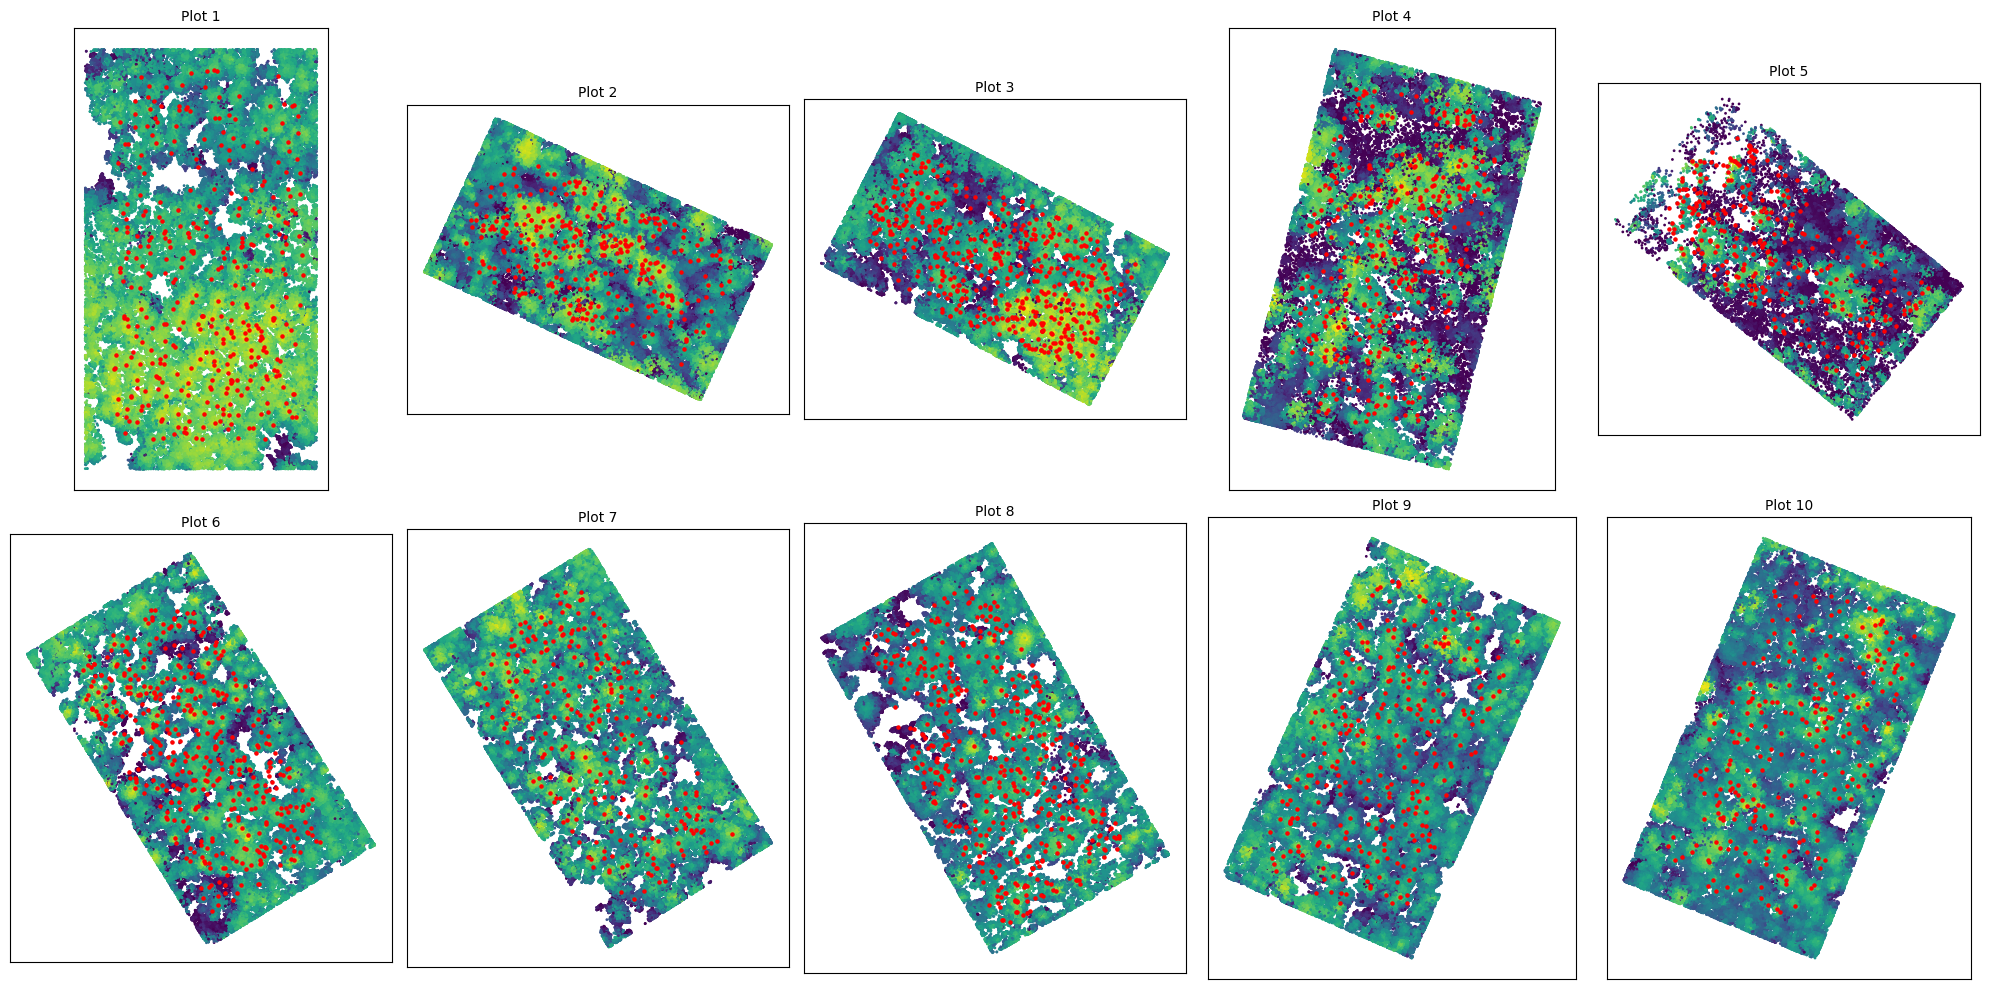

In [26]:
fig, axes = plt.subplots(2, 5, figsize=(20, 10))
axes = axes.flatten()

for idx, (plot, matches) in enumerate(raw_matches.items()):
    cloud = preprocessed_data[plot - 1]
    local_maxima = np.array([
        m["candidate"] for m in matches if m["class"] in ["TP", "FP"]
    ])

    ax = axes[idx]

    sc = ax.scatter(cloud[:, 0], cloud[:, 1], c=cloud[:, 2], s=1, cmap="viridis")

    # Plot local maxima in red
    if len(local_maxima) > 0:
        ax.scatter(local_maxima[:, 0], local_maxima[:, 1], c="red", s=5, label="Local Maxima")

    ax.set_title(f"Plot {plot}", fontsize=10)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

In [62]:
import numpy as np
import h5py
import sys

class DataLoader:
    def __init__(self, data, xyz_index=(0,1,2), ext=False):
        """
        Initializes the DataLoader with a list of point clouds (preprocessed data).
        Each item in the list should be a NumPy array of shape (n_points, 3).
        """
        self.d = data  # Expecting a list of point clouds (arrays)
        self.ext = ext
        self.x, self.y, self.z = xyz_index

    def __call__(self, xyz_range=None, threshold=10, mag_coeff=100, _format='xyzrgbl'):
        """
        Converts point cloud data into voxel grid representation.
        """
        # Determine the range of x, y, z coordinates
        if not xyz_range:
            xyz_range = [int(itm) for itm in [
                min(self.d[0][:, self.x]), min(self.d[0][:, self.y]), min(self.d[0][:, self.z]),
                max(self.d[0][:, self.x]), max(self.d[0][:, self.y]), max(self.d[0][:, self.z])
            ]]

        # Process the list of point clouds
        full_list, list_matrix, label_matrix = self.__get_list_matrix__(xyz_range)
        threeD_xyz_rgb_label, threeD_matrix, threeD_label = self.__get_3D_matrix__(
            full_list, list_matrix, xyz_range, mag_coeff, _format
        )

        return threeD_xyz_rgb_label, threeD_matrix, threeD_label, list_matrix, label_matrix

    def __get_list_matrix__(self, xyz_range):
        """
        Filters the point cloud data based on the xyz_range.
        """
        full_list = np.vstack(self.d)  # Stack all point clouds into a single array
        lx, ly, lz, hx, hy, hz = xyz_range

        # Apply the range filtering
        filtered = full_list[
            (full_list[:, self.x] >= lx) & (full_list[:, self.x] < hx) &
            (full_list[:, self.y] >= ly) & (full_list[:, self.y] < hy) &
            (full_list[:, self.z] >= lz) & (full_list[:, self.z] < hz)
        ]
        return filtered, filtered[:, :-1], filtered[:, (self.x, self.y, self.z)]

    def __get_3D_matrix__(self, full_list, list_matrix, xyz_range, mag_coeff, _format):
        """
        Converts the filtered list of points into a 3D voxel grid.
        """
        lx, ly, lz, hx, hy, hz = xyz_range
        magnifier = int(mag_coeff) / (hx - lx)
        dx, dy, dz = map(int, [(hx - lx) * magnifier, (hy - ly) * magnifier, (hz - lz) * magnifier])

        # Initialize the 3D matrices
        threeD_xyz_rgb_label = np.zeros(shape=[dx, dy, dz, 3], dtype=np.float32)  # Only xyz
        threeD_matrix = np.zeros(shape=[dx, dy, dz, 3], dtype=np.float32)  # Only xyz
        threeD_label = np.zeros(shape=[dx, dy, dz], dtype=np.float32)

        # Populate the 3D matrices with data
        for itm in full_list:
            x, y, z = itm[[self.x, self.y, self.z]]
            i, j, k = [
                int((x - lx) * magnifier) - 1,
                int((y - ly) * magnifier) - 1,
                int((z - lz) * magnifier) - 1
            ]
            threeD_xyz_rgb_label[i, j, k] = itm  # Store only xyz
            threeD_matrix[i, j, k] = itm  # Store only xyz
            threeD_label[i, j, k] = 0  # No label provided, set to 0 (or another placeholder)

        return threeD_xyz_rgb_label, threeD_matrix, threeD_label

    def __xyz_range__(self):
        """
        Calculates the range of x, y, z coordinates.
        """
        full_list = np.vstack(self.d)
        x_min, y_min, z_min = np.min(full_list, axis=0)[:3]
        x_max, y_max, z_max = np.max(full_list, axis=0)[:3]
        return x_min, y_min, z_min, x_max, y_max, z_max

def save_voxel_grids_to_hdf5(preprocessed_data, output_file, voxel_size=0.1):
    """
    Converts the preprocessed point clouds to voxel grids and saves them as an HDF5 file.
    :param preprocessed_data: List of NumPy arrays representing point clouds
    :param output_file: Path to save the HDF5 file
    :param voxel_size: Size of each voxel
    """
    data_loader = DataLoader(preprocessed_data, (0, 1, 2))
    xyz_range = data_loader.__xyz_range__()

    # Convert to voxel grids
    full_mat, threeD_mat, threeD_label, list_mat, label_mat = data_loader(xyz_range, 10, 100)

    # Save voxel grids to HDF5
    with h5py.File(output_file, 'w') as h5f:
        h5f.create_dataset('voxel_grid', data=full_mat)
        h5f.create_dataset('3d_matrix', data=threeD_mat)
        h5f.create_dataset('3d_label', data=threeD_label)

    print(f"Voxel grid saved to {output_file}")

In [63]:
if __name__ == "__main__":

    output_file = "output_data.h5"  # Path to save the voxel grid
    save_voxel_grids_to_hdf5(preprocessed_data, output_file)


Voxel grid saved to output_data.h5


In [64]:
import h5py

# Open the saved HDF5 file
with h5py.File('output_data.h5', 'r') as h5f:
    # List all datasets inside the file
    print("Datasets in HDF5 file:", list(h5f.keys()))

    # Access the voxel grid dataset
    voxel_grid = h5f['voxel_grid'][:]
    print("Voxel Grid Shape:", voxel_grid.shape)

    # Access other datasets (if needed)
    threeD_matrix = h5f['3d_matrix'][:]
    threeD_label = h5f['3d_label'][:]
    print("3D Matrix Shape:", threeD_matrix.shape)
    print("3D Label Shape:", threeD_label.shape)

Datasets in HDF5 file: ['3d_label', '3d_matrix', 'voxel_grid']
Voxel Grid Shape: (100, 87, 2, 3)
3D Matrix Shape: (100, 87, 2, 3)
3D Label Shape: (100, 87, 2)


In [59]:
field_survey_gpd['x'] = field_survey_gpd.geometry.x
field_survey_gpd['y'] = field_survey_gpd.geometry.y
field_survey_gpd['z'] = field_survey_gpd['height'].fillna(0)

In [67]:
min_coord = (field_survey_gpd['x'].min(), field_survey_gpd['y'].min(), field_survey_gpd['z'].min())
max_coord = (field_survey_gpd['x'].max(), field_survey_gpd['y'].max(), field_survey_gpd['z'].max())
print(min_coord)
print(max_coord)

(545536.27, 6449027.57899999, 0.0)
(547122.655999999, 6450428.445, 34.2)


In [65]:
voxel_min = np.min(voxel_grid)
voxel_max = np.max(voxel_grid)

print("Minimum value in voxel grid:", voxel_min)
print("Maximum value in voxel grid:", voxel_max)


Minimum value in voxel grid: 0.0
Maximum value in voxel grid: 6450423.5


In [69]:
import numpy as np

def assign_labels_to_voxel_grid(voxel_grid, field_survey_gpd, voxel_min, voxel_max):
    """
    Assign labels (1 for tree present, 0 for no tree) to a 3D voxel grid.

    Parameters:
    - voxel_grid: 3D numpy array representing the voxel grid (initialized with 0s).
    - field_survey_gpd: DataFrame containing the field survey data (tree coordinates and heights).
    - voxel_min: Minimum coordinates of the voxel grid (3D).
    - voxel_max: Maximum coordinates of the voxel grid (3D).

    Returns:
    - labels: 3D numpy array with voxel labels (1 for tree, 0 for empty).
    """
    # Get the dimensions of the voxel grid
    D, H, W = voxel_grid.shape[:3]  # Dimensions of voxel grid (depth, height, width)

    # Initialize labels array with zeros (0 for no tree)
    labels = np.zeros((D, H, W), dtype=int)

    # Calculate voxel size based on real-world coordinates and voxel grid shape
    voxel_size = (voxel_max - voxel_min) / np.array([D - 1, H - 1, W - 1])

    # Iterate over trees in the field survey data
    for _, row in field_survey_gpd.iterrows():
        # Extract the tree's real-world coordinates
        tree_coords = np.array([row['x'], row['y'], row['z']])

        # Map the tree's real-world coordinates to voxel grid indices
        voxel_indices = np.round(
            (tree_coords - voxel_min) / voxel_size
        ).astype(int)

        # Clip indices to ensure they are within the bounds of the voxel grid
        voxel_indices = np.clip(voxel_indices, [0, 0, 0], [D - 1, H - 1, W - 1])

        # Assign label '1' to the corresponding voxel
        labels[tuple(voxel_indices)] = 1

    return labels


# Define the voxel grid's min and max bounds (real-world coordinates)
voxel_min = np.array([field_survey_gpd['x'].min(), field_survey_gpd['y'].min(), field_survey_gpd['z'].min()])
voxel_max = np.array([field_survey_gpd['x'].max(), field_survey_gpd['y'].max(), field_survey_gpd['z'].max()])



# Assign labels to the voxel grid
labels = assign_labels_to_voxel_grid(voxel_grid, field_survey_gpd, voxel_min, voxel_max)

In [70]:
np.unique(labels)

array([0, 1])

In [71]:
# Output information for verification
print("Labels shape:", labels.shape)
print("Unique labels and counts:", np.unique(labels, return_counts=True))

Labels shape: (100, 87, 2)
Unique labels and counts: (array([0, 1]), array([16923,   477]))


In [75]:
voxel_grid.shape

(100, 87, 2, 3)

In [85]:
labels.shape

(100, 87, 2, 1)

In [84]:
labels = labels[..., np.newaxis]  # Adds a new axis to make the shape (100, 87, 2, 1)


In [126]:
X = voxel_grid  # Input features
y = labels  # Output labels

# Split into train and test (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train Shape:", X_train.shape,y_train.shape)
print("Test Shape:", X_test.shape,y_test.shape)

Train Shape: (80, 87, 2, 3) (80, 87, 2, 1)
Test Shape: (20, 87, 2, 3) (20, 87, 2, 1)


In [109]:
np.unique(y_test)

array([0, 1])

In [113]:
unique, counts = np.unique(y_test, return_counts=True)
print("Class distribution in y_test:", dict(zip(unique, counts)))


Class distribution in y_test: {0: 3382, 1: 98}


In [136]:
# Updated 3D CNN model
def build_3d_cnn(input_shape):
    model = models.Sequential()

    # Input layer
    model.add(layers.Input(shape=input_shape))

    # 3D Convolution Layer 1
    model.add(layers.Conv3D(32, kernel_size=(2, 2, 2), activation='relu', padding='same'))
    model.add(layers.MaxPooling3D(pool_size=(1, 2, 1)))

    # 3D Convolution Layer 2
    model.add(layers.Conv3D(64, kernel_size=(2, 2, 2), activation='relu', padding='same'))
    model.add(layers.MaxPooling3D(pool_size=(1, 2, 1)))

    # Flatten
    model.add(layers.Flatten())

    # Fully connected layers
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dense(64, activation='relu'))

    # Output layer: Predict 87 × 2 labels per sample
    model.add(layers.Dense(87 * 2, activation='sigmoid'))  # 174 outputs per sample
    model.add(layers.Reshape((87, 2, 1)))  # Reshape to match (87, 2, 1)

    # Compile the model
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    return model

# Define input shape: (1, 87, 2, 3)
input_shape = (1, X_train.shape[1], X_train.shape[2], X_train.shape[3])

# Build the corrected model
model = build_3d_cnn(input_shape)

# Print summary
model.summary()


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv3d_11 (Conv3D)                   │ (None, 1, 87, 2, 32)        │             800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling3d_8 (MaxPooling3D)       │ (None, 1, 43, 2, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3d_12 (Conv3D)                   │ (None, 1, 43, 2, 64)        │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling3d_9 (MaxPooling3D)       │ (None, 1, 21, 2, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_4 (Flatten)                  │ (None, 2688)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 128)                 │         344,192 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 174)                 │          11,310 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape (Reshape)                    │ (None, 87, 2, 1)            │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 381,006 (1.45 MB)

 Trainable params: 381,006 (1.45 MB)

 Non-trainable params: 0 (0.00 B)

In [137]:
X_test_reshaped = X_test.reshape(-1, 1, X_test.shape[1], X_test.shape[2], X_test.shape[3])

# Get predictions from the model
y_pred_prob = model.predict(X_test_reshaped)  # Shape: (20, 87, 2, 1)

# Flatten predictions and ground truth
y_pred_flat = y_pred_prob.flatten()  # Shape: (3480,)
y_test_flat = y_test.flatten()       # Shape: (3480,)

# Convert probabilities to binary labels
y_pred = (y_pred_flat > 0.5).astype(int)

# Calculate metrics
accuracy = accuracy_score(y_test_flat, y_pred)
precision = precision_score(y_test_flat, y_pred)
recall = recall_score(y_test_flat, y_pred)
f1 = f1_score(y_test_flat, y_pred)

# Print results
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-Score:", f1)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
Accuracy: 0.6718390804597701
Precision: 0.04608695652173913
Recall: 0.5408163265306123
F1-Score: 0.08493589743589744
